# Mesh-Independence Validation

A mesh-independence study was performed on the baseline aluminium heat-sink model to verify that the predicted maximum temperature was not materially affected by mesh refinement.

All geometry, materials, thermal loads and boundary conditions were held constant while only the global element size was changed.

**Acceptance criterion:** the final refinement should change the predicted **temperature rise above ambient** by less than **2%**. The absolute temperature change is reported alongside the percentage. Temperature-rise normalisation is used because percentage changes in Celsius temperature itself are not physically meaningful.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ambient_temperature = 25.0  # °C

mesh_results = pd.DataFrame({
    "Mesh": ["Coarse", "Medium", "Fine"],
    "Global Element Size (mm)": [5.0, 2.5, 2.0],
    "Maximum Temperature (°C)": [30.628, 30.631, 30.633],
})

mesh_results["Temperature Rise Above Ambient (°C)"] = (
    mesh_results["Maximum Temperature (°C)"] - ambient_temperature
)
mesh_results["Absolute Change from Previous (°C)"] = (
    mesh_results["Maximum Temperature (°C)"].diff().abs()
)
mesh_results["Change in Temperature Rise from Previous (%)"] = (
    mesh_results["Temperature Rise Above Ambient (°C)"].pct_change().abs() * 100
)

mesh_results.round(4)

,Mesh,Global Element Size (mm),Maximum Temperature (°C),Temperature Rise Above Ambient (°C),Absolute Change from Previous (°C),Change in Temperature Rise from Previous (%)
0,Coarse,5.0,30.628,5.628,NaN,NaN
1,Medium,2.5,30.631,5.631,0.003,0.0533
2,Fine,2.0,30.633,5.633,0.002,0.0355


In [2]:
coarse_temp = mesh_results["Maximum Temperature (°C)"].iloc[0]
medium_temp = mesh_results["Maximum Temperature (°C)"].iloc[1]
fine_temp = mesh_results["Maximum Temperature (°C)"].iloc[2]

coarse_rise = coarse_temp - ambient_temperature
medium_rise = medium_temp - ambient_temperature
fine_rise = fine_temp - ambient_temperature

medium_to_fine_abs = abs(fine_temp - medium_temp)
coarse_to_fine_abs = abs(fine_temp - coarse_temp)

medium_to_fine_rise_pct = medium_to_fine_abs / medium_rise * 100
coarse_to_fine_rise_pct = coarse_to_fine_abs / coarse_rise * 100

print(f"Medium-to-fine absolute temperature change: {medium_to_fine_abs:.4f} °C")
print(f"Coarse-to-fine absolute temperature change: {coarse_to_fine_abs:.4f} °C")
print(f"Medium-to-fine change relative to temperature rise: {medium_to_fine_rise_pct:.4f}%")
print(f"Coarse-to-fine change relative to temperature rise: {coarse_to_fine_rise_pct:.4f}%")
print("Mesh-independence criterion: < 2% change in temperature rise")

Medium-to-fine absolute temperature change: 0.0020 °C
Coarse-to-fine absolute temperature change: 0.0050 °C
Medium-to-fine change relative to temperature rise: 0.0355%
Coarse-to-fine change relative to temperature rise: 0.0888%
Mesh-independence criterion: < 2% change in temperature rise


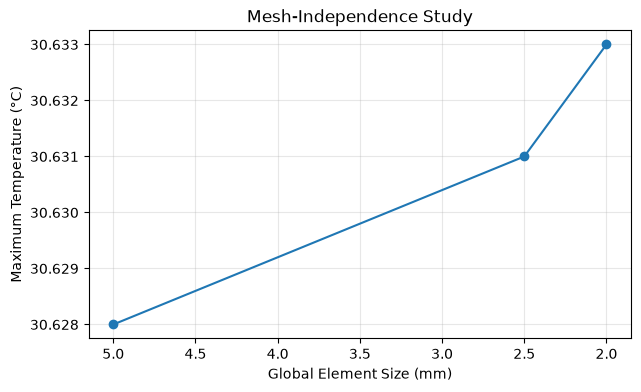

In [3]:
plt.figure(figsize=(7, 4))

plt.plot(
    mesh_results["Global Element Size (mm)"],
    mesh_results["Maximum Temperature (°C)"],
    marker="o"
)

plt.xlabel("Global Element Size (mm)")
plt.ylabel("Maximum Temperature (°C)")
plt.title("Mesh-Independence Study")

plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

### Mesh-Independence Result

The predicted maximum temperature changed only slightly as the mesh was refined:

- **5.0 mm mesh:** 30.628°C
- **2.5 mm mesh:** 30.631°C
- **2.0 mm mesh:** 30.633°C

The medium-to-fine refinement changes the predicted maximum temperature by only **0.002°C**, equivalent to approximately **0.0355% of the medium-mesh temperature rise above the 25°C ambient**. The total coarse-to-fine change is **0.005°C**, equivalent to approximately **0.0888% of the coarse-mesh temperature rise**.

Both values are substantially below the predefined **2% mesh-independence criterion**, so the thermal solution is effectively mesh-independent over the tested range.

A further refinement to **1.25 mm** was attempted, but the resulting node and element count exceeded the ANSYS Student solver limit. This does not undermine the convergence conclusion because the solution had already stabilised well before this refinement.

The **2.5 mm medium mesh** is therefore selected as the project mesh because it is already converged while avoiding the additional computational cost of the 2.0 mm mesh.